# Notebook Análisis de las Series de Tiempo
**CC3084 - Laboratorio 1: Series de Tiempo**

*Rodrigo Ajmac - 22279*

*Andres Mazariegos - 21749*

*June Herrera - 231038*

## 0. Configuración

**Librerías**

In [88]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import openpyxl
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

**Dependencias**

In [2]:
data_viajes = '../Datos_Crudos/Base_Migracion_2009-2026jun.xlsx'

**Funciones**

## 1. Procesamiento de Datos

In [62]:
# Leer archivo .xlsx con los datos
df = pd.read_excel(data_viajes)

In [70]:
# Colocar columna de viajero como entero para evitar incongruencias
df['Viajero'] = df['Viajero'].astype(int)

In [71]:
# Agregar columna de fecha
df['fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes cod'].astype(str).str.zfill(2) + '-01'
)

In [72]:
# Verificar que los datos se cargan correctamente
df.head()

,Año,Mes cod,Mes,Vía,Frontera,País,Región,Región dos,Regiones OMT,MCEO,Agrupación Residencia,Tipo de Viajero,Viajero,fecha
0,2009,1,Ene,Aérea,01 La Aurora,Albania,OTROS EUROPEOS,Europa,EUROPA MERIDIONAL,08 OTROS,Europa,Turista,1,2009-01-01
1,2009,1,Ene,Aérea,01 La Aurora,Alemania,EUROPA,Europa,EUROPA OCCIDENTAL,04 EUROPA,Europa,Turista,716,2009-01-01
2,2009,1,Ene,Aérea,01 La Aurora,Angola,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA CENTRAL,08 OTROS,Resto del Mundo,Turista,4,2009-01-01
3,2009,1,Ene,Aérea,01 La Aurora,Arabia Saudita,OTROS ORIENTE MEDIO,Oriente Medio,ORIENTE MEDIO,08 OTROS,Resto del Mundo,Turista,5,2009-01-01
4,2009,1,Ene,Aérea,01 La Aurora,Argelia,OTROS PAISES DEL MUNDO,Otros Paises Del Mundo,ÁFRICA DEL NORTE,08 OTROS,Resto del Mundo,Turista,1,2009-01-01


### Serie General de Viajeros por Mes

In [82]:
# Agrupar total viajeros de cada mes 
df_general = df.groupby(['fecha'])['Viajero'].sum()

In [83]:
df_general.head()

fecha
2009-01-01    183454
2009-02-01    149376
2009-03-01    174177
2009-04-01    182787
2009-05-01    133129
Name: Viajero, dtype: int64

### Top 3 Países con Más Viajeros

In [91]:
top5_paises = (
    df.groupby('País')['Viajero']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

print(top5_paises)

País
El Salvador                  16212162
Guatemala                    14790279
Estados Unidos de América     7046014
Honduras                      2786735
México                        1807111
Name: Viajero, dtype: int64


#### Serie para El Salvador

In [105]:
df_salvador = df[df['País']=='El Salvador']
df_salvador_copy = df_salvador
df_salvador = df_salvador.groupby(['fecha'])['Viajero'].sum()

In [106]:
df_salvador.head()

fecha
2009-01-01    31602
2009-02-01    26605
2009-03-01    34544
2009-04-01    35522
2009-05-01    27166
Name: Viajero, dtype: int64

## 2. Gráficos y Compenetes de las Series

### Serie General de Viajeros por Mes

<Axes: title={'center': 'Cantidad de viajeros por mes'}, xlabel='fecha'>

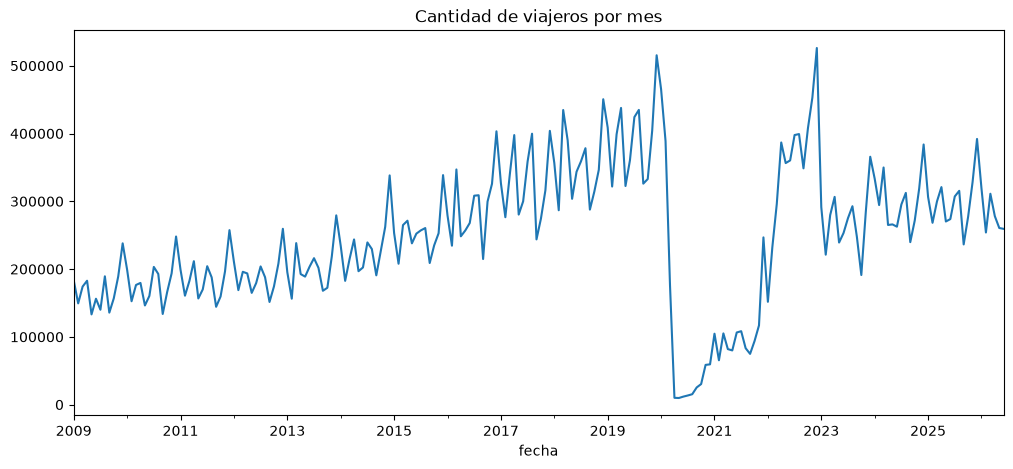

In [107]:
df_general.plot(figsize=(12, 5), title='Cantidad de viajeros por mes')

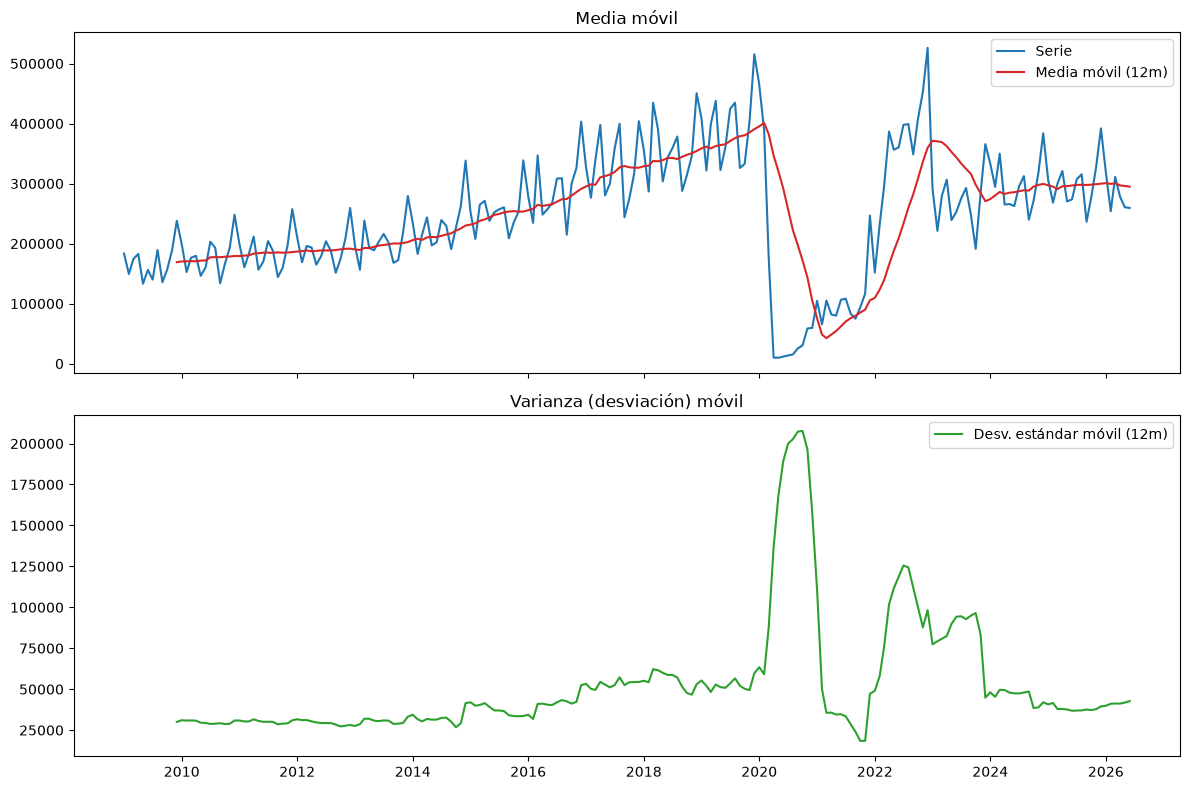

In [108]:
ventana = 12
media_movil = df_general.rolling(ventana).mean()
std_movil = df_general.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_general, label="Serie", color="#1f77b4")
ax[0].plot(media_movil, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil"); ax[0].legend()

ax[1].plot(std_movil, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil"); ax[1].legend()
plt.tight_layout(); plt.show()

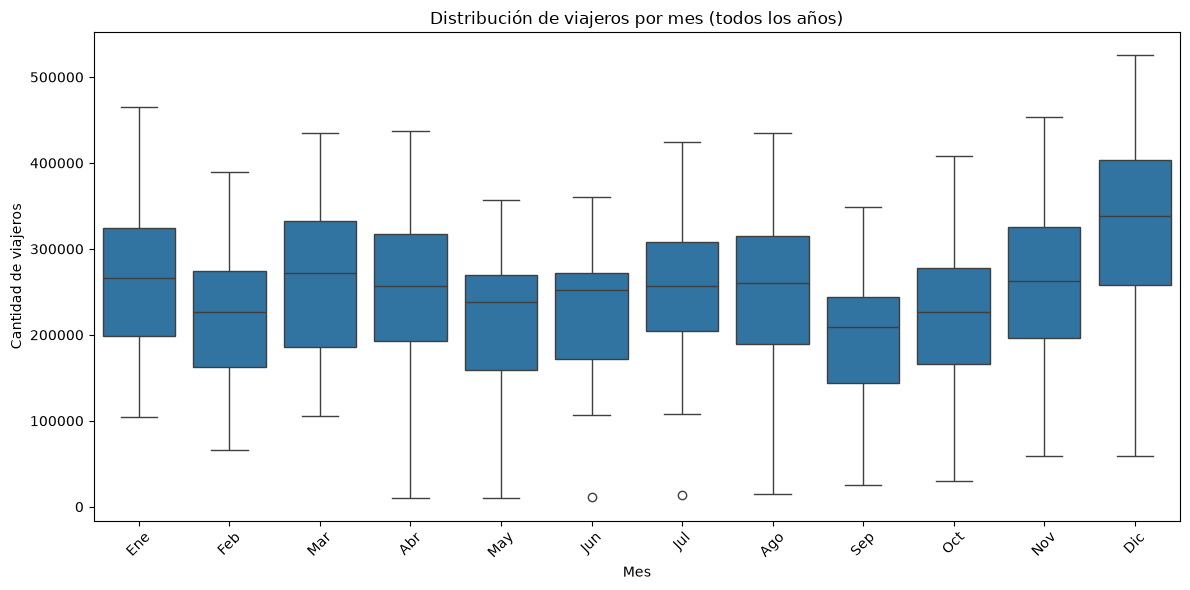

In [ ]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (todos los años)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

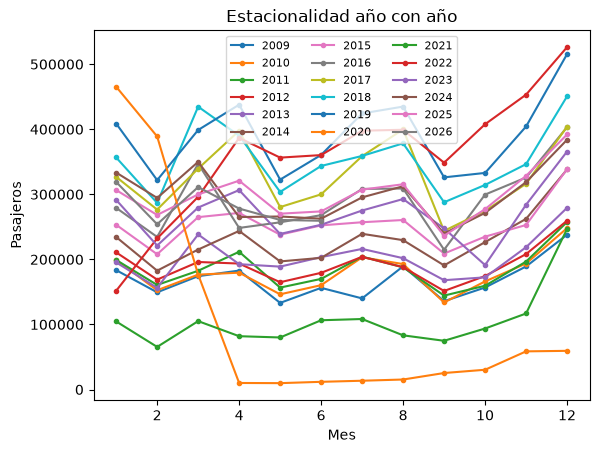

In [120]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()

#### Serie para Viajeros de El Salvador (Top 1)

<Axes: title={'center': 'Cantidad de viajeros por mes (Originarios de El Salvador)'}, xlabel='fecha'>

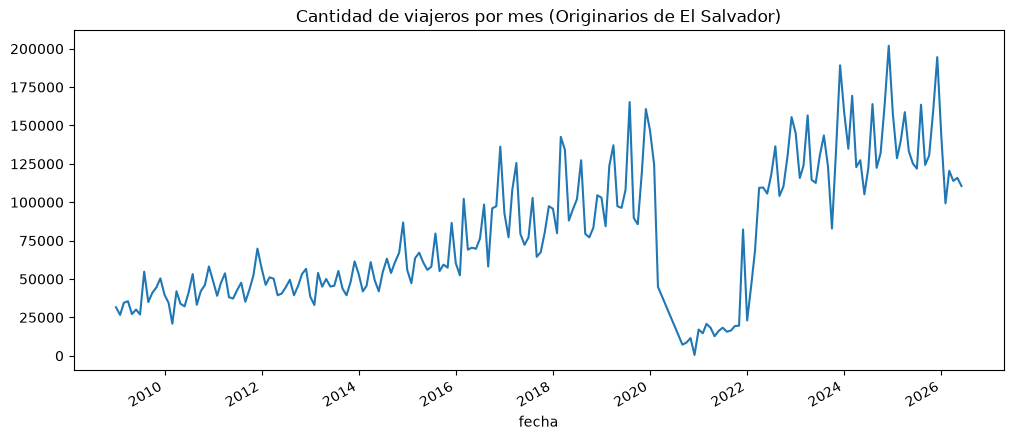

In [110]:
df_salvador.plot(figsize=(12, 5), title='Cantidad de viajeros por mes (Originarios de El Salvador)')

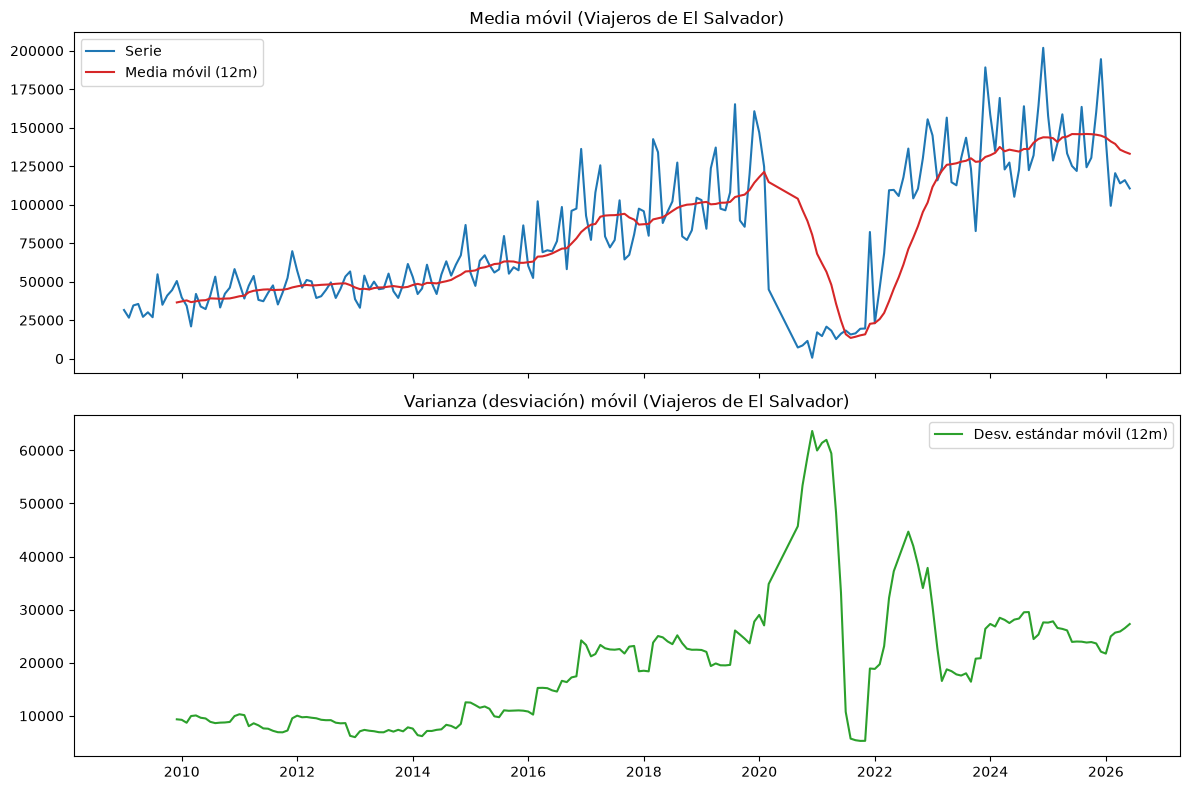

In [111]:
media_movil_slv = df_salvador.rolling(ventana).mean()
std_movil_slv = df_salvador.rolling(ventana).std()

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(df_salvador, label="Serie", color="#1f77b4")
ax[0].plot(media_movil_slv, label=f"Media móvil ({ventana}m)", color="#d62728")
ax[0].set_title("Media móvil (Viajeros de El Salvador)"); ax[0].legend()

ax[1].plot(std_movil_slv, label=f"Desv. estándar móvil ({ventana}m)", color="#2ca02c")
ax[1].set_title("Varianza (desviación) móvil (Viajeros de El Salvador)"); ax[1].legend()
plt.tight_layout(); plt.show()

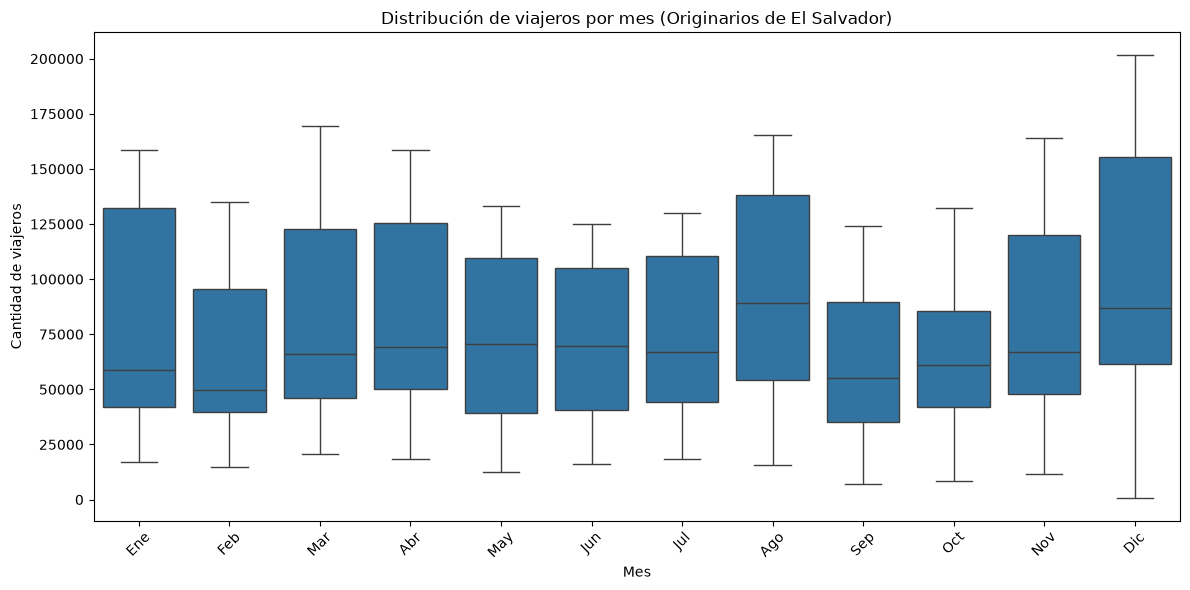

In [113]:
# Primero agrupamos por Año y Mes para tener el total de viajeros de cada combinación
datos_boxplot = df_salvador_copy.groupby(['Año', 'Mes cod', 'Mes'])['Viajero'].sum().reset_index()

# Ordenamos los meses cronológicamente (usando Mes cod para el orden correcto)
orden_meses = datos_boxplot.sort_values('Mes cod')['Mes'].unique()

# Creamos el boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=datos_boxplot,
    x='Mes',
    y='Viajero',
    order=orden_meses
)

plt.title('Distribución de viajeros por mes (Originarios de El Salvador)')
plt.xlabel('Mes')
plt.ylabel('Cantidad de viajeros')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

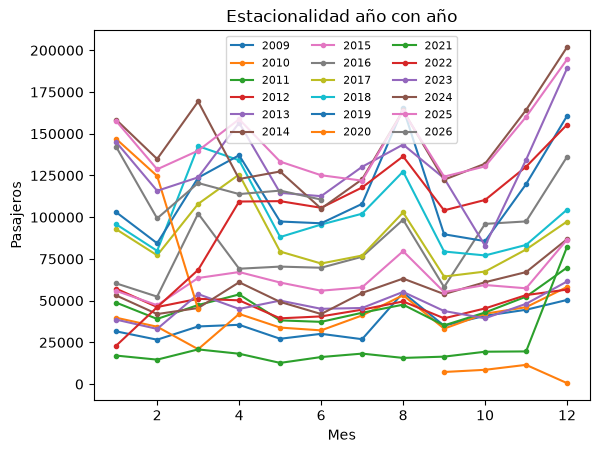

In [121]:
# Cada año como una curva -> se ve que el patrón se repite y se agranda
piv = df_salvador_copy.groupby(['Año','Mes cod'])['Viajero'].sum().reset_index().pivot_table(index="Mes cod", columns="Año", values="Viajero")
plt.figure()
for col in piv.columns:
    plt.plot(piv.index, piv[col], marker="o", markersize=3, label=col)
plt.title("Estacionalidad año con año")
plt.xlabel("Mes"); plt.ylabel("Pasajeros")
plt.legend(ncol=3, fontsize=8); plt.show()